Data Exploration & Preprocessing

In [3]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [4]:
# Load Dataset

df = pd.read_csv("sonardataset.csv", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
1,0.02,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.018,0.0084,0.009,0.0032,R
2,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.014,0.0049,0.0052,0.0044,R
3,0.0262,0.0582,0.1099,0.1083,0.0974,0.228,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.018,0.0244,0.0316,0.0164,0.0095,0.0078,R
4,0.01,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.015,0.0085,0.0073,0.005,0.0044,0.004,0.0117,R


Dataset Information

In [5]:
print("Shape of Dataset :", df.shape)

Shape of Dataset : (209, 61)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       209 non-null    object
 1   1       209 non-null    object
 2   2       209 non-null    object
 3   3       209 non-null    object
 4   4       209 non-null    object
 5   5       209 non-null    object
 6   6       209 non-null    object
 7   7       209 non-null    object
 8   8       209 non-null    object
 9   9       209 non-null    object
 10  10      209 non-null    object
 11  11      209 non-null    object
 12  12      209 non-null    object
 13  13      209 non-null    object
 14  14      209 non-null    object
 15  15      209 non-null    object
 16  16      209 non-null    object
 17  17      209 non-null    object
 18  18      209 non-null    object
 19  19      209 non-null    object
 20  20      209 non-null    object
 21  21      209 non-null    object
 22  22      209 non-null    ob

In [7]:
df.describe().T

,count,unique,top,freq
0,209,178,0.0201,5
1,209,183,0.0523,2
2,209,191,0.0623,2
3,209,182,0.0608,3
4,209,194,0.0647,2
...,...,...,...,...
56,209,122,0.0037,7
57,209,125,0.0036,6
58,209,120,0.007,6
59,209,110,0.0053,7



Check Missing Values

In [8]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
56,0
57,0
58,0
59,0


Duplicate Values

In [9]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


Class Distribution

In [10]:
df[60].value_counts()

,count
60,
M,111
R,97
Y,1


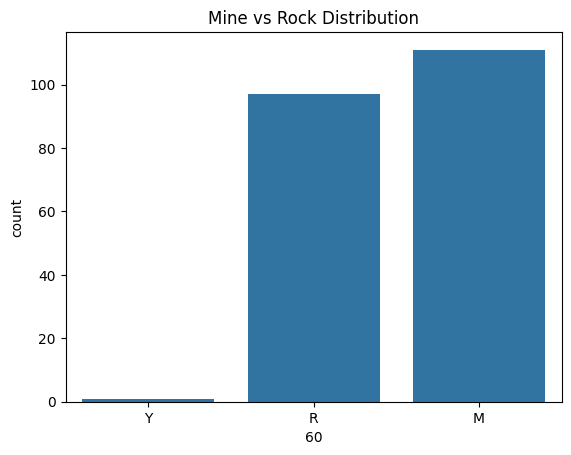

In [11]:
sns.countplot(x=df[60])
plt.title("Mine vs Rock Distribution")
plt.show()

Separate Features & Target

In [24]:
# Filter out the 'Y' class from the dataset
df_filtered = df.loc[df[60] != 'Y'].copy()

X = df_filtered.iloc[1:,0:60].astype(float)
y = df_filtered.iloc[1:,60]

# Apply LabelEncoder to ensure y is numerical (0 or 1)
encoder = LabelEncoder()
y = encoder.fit_transform(y)

Encode Labels

In [28]:
# Label encoding moved to cell EzOU1Ey_TPHz to ensure y is numerical before train_test_split.
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(np.unique(y))

[0 1]


Normalize Features

In [17]:
scaler = StandardScaler()
X = scaler.fit_transform(X.values)

Train Test Split

In [31]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Explicitly convert X_train and X_test to numpy arrays of float32
X_train = np.asarray(X_train).astype(np.float32)
X_test = np.asarray(X_test).astype(np.float32)

# Explicitly convert y_train and y_test to numpy arrays of integers
y_train = np.asarray(y_train).astype(int)
y_test = np.asarray(y_test).astype(int)

print(X_train.shape)
print(X_test.shape)

(165, 60)
(42, 60)


Build ANN Model

In [32]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Create Model

In [33]:
model = Sequential()

model.add(Dense(32,
                input_dim=60,
                activation='relu'))

model.add(Dense(16,
                activation='relu'))

model.add(Dense(1,
                activation='sigmoid'))

Compile Model

In [34]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Model Summary

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [37]:
history=model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9848 - loss: 0.1357 - val_accuracy: 0.7576 - val_loss: 0.5246
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9848 - loss: 0.1324 - val_accuracy: 0.7273 - val_loss: 0.5188
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9848 - loss: 0.1344 - val_accuracy: 0.8182 - val_loss: 0.5184
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9697 - loss: 0.1325 - val_accuracy: 0.7576 - val_loss: 0.5398
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9773 - loss: 0.1278 - val_accuracy: 0.7879 - val_loss: 0.5032
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9848 - loss: 0.1285 - val_accuracy: 0.7576 - val_loss: 0.5522
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9848 - loss: 0.1236 - val_accuracy: 0.8182 - val_loss: 0.4970
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9848 - loss: 0.1250 - val_accuracy: 0.7576 - val_loss: 

Plot Accuracy

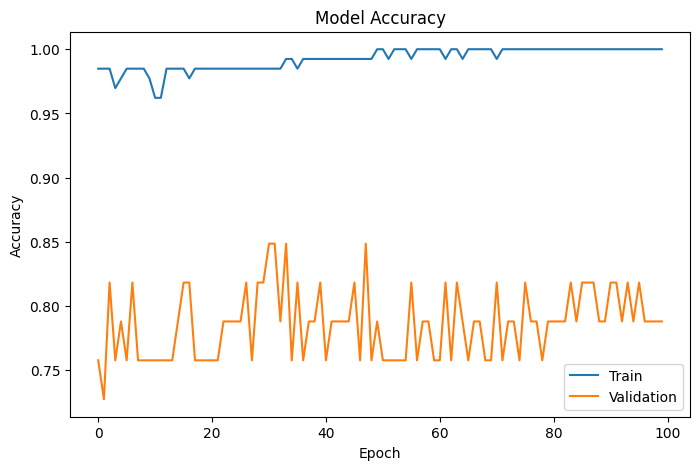

In [38]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

Plot Loss

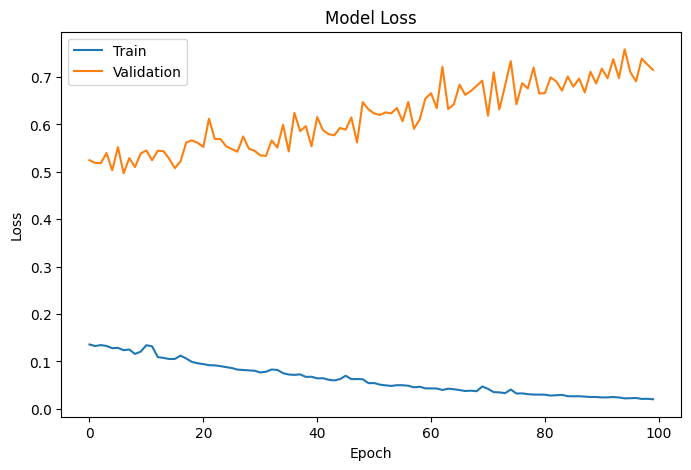

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

Prediction

In [40]:
y_pred=model.predict(X_test)
y_pred=(y_pred>0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


Evaluation

In [41]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Accuracy

In [42]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy :",accuracy)

Accuracy : 0.6904761904761905


Precision

In [43]:
precision=precision_score(y_test,y_pred)
print("Precision :",precision)

Precision : 0.75


Recall

In [44]:
recall=recall_score(y_test,y_pred)
print("Recall :",recall)

Recall : 0.47368421052631576


F1 Score

In [45]:
f1=f1_score(y_test,y_pred)
print("F1 Score :",f1)

F1 Score : 0.5806451612903226


Classification Report

In [46]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      0.87      0.75        23
           1       0.75      0.47      0.58        19

    accuracy                           0.69        42
   macro avg       0.71      0.67      0.67        42
weighted avg       0.70      0.69      0.68        42



Confusion Matrix

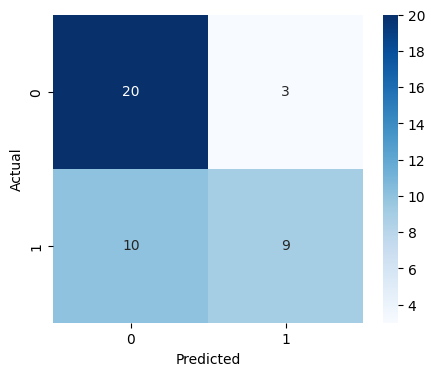

In [47]:
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Hyperparameter Tuning

Function

In [48]:
from tensorflow.keras.optimizers import Adam

def build_model(neurons=32,
                hidden_layers=1,
                learning_rate=0.001,
                activation='relu'):

    model=Sequential()

    model.add(Dense(neurons,
                    input_dim=60,
                    activation=activation))

    for i in range(hidden_layers-1):

        model.add(Dense(neurons,
                        activation=activation))

    model.add(Dense(1,
                    activation='sigmoid'))

    optimizer=Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

Different Models

Model 1

In [49]:
model1=build_model(
    neurons=32,
    hidden_layers=1,
    learning_rate=0.001
)

history1=model1.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    verbose=0
)

score1=model1.evaluate(X_test,y_test)

print(score1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7619 - loss: 0.5285 
[0.5285273194313049, 0.761904776096344]


Model 2

In [50]:
model2=build_model(
    neurons=64,
    hidden_layers=2,
    learning_rate=0.001
)

history2=model2.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=16,
    verbose=0
)

score2=model2.evaluate(X_test,y_test)

print(score2)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7381 - loss: 1.2324 
[1.2324491739273071, 0.738095223903656]


Model 3

In [51]:
model3=build_model(
    neurons=128,
    hidden_layers=3,
    learning_rate=0.0005
)

history3=model3.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=8,
    verbose=0
)

score3=model3.evaluate(X_test,y_test)

print(score3)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7619 - loss: 2.0179 
[2.017879009246826, 0.761904776096344]


Compare Models

In [52]:
comparison=pd.DataFrame({

    "Model":[
        "Default",
        "Model-2",
        "Model-3"
    ],

    "Accuracy":[
        score1[1],
        score2[1],
        score3[1]
    ]

})

comparison

,Model,Accuracy
0,Default,0.761905
1,Model-2,0.738095
2,Model-3,0.761905


Best Model Prediction

In [53]:
best_pred=model3.predict(X_test)
best_pred=(best_pred>0.5).astype(int)
print(classification_report(y_test,best_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
              precision    recall  f1-score   support

           0       0.72      0.91      0.81        23
           1       0.85      0.58      0.69        19

    accuracy                           0.76        42
   macro avg       0.79      0.75      0.75        42
weighted avg       0.78      0.76      0.75        42



Final Conclusion

In [54]:
print("Default Model Accuracy :",score1[1])
print("Tuned Model Accuracy :",score3[1])

if score3[1]>score1[1]:
    print("Hyperparameter tuning improved the ANN performance.")
else:
    print("Default model performed better.")

Default Model Accuracy : 0.761904776096344
Tuned Model Accuracy : 0.761904776096344
Default model performed better.
